In [1]:
#Перед вами данные взаимодействий с рекламными объявлениями на некоторой площадке за 6 дней. И таблица с характеристиками рекламных клиентов (тех, кто разместил эти объявления).

#Задачи
#1.	Разберемся с распределением количества показов и кликов. Посчитайте среднее количество показов и среднее количество кликов на объявления за весь период (округлите до целых).
#2.	Нарисуйте график распределения показов на объявление за весь период.
#3.	Давайте посчитаем скользящее среднее показов с окном 2. Какое значение скользящего среднего получим за 6 апреля 2019 года (ответ округлите до целых)?
#4.	Скользящее среднее часто используется для поиска аномалий в данных. Давайте попробуем нанести на один график значения арифметического среднего по дням и скользящего среднего количества показов. В какой день наблюдается наибольшая разница по модулю между арифметическим средним и скользящим средним? Дни, в которых скользящее среднее равно NaN, не учитываем.
#5.	*Напишите функцию, которая найдет проблемное объявление (с наибольшим/наименьшим количеством показов) в день, в который была замечена самая большая по модулю аномалия.
#6.	Теперь подгрузим данные по рекламным клиентам и найдем среднее количество дней от даты создания рекламного клиента и первым запуском рекламного объявления этим клиентом.
#7.	Вычислите конверсию из создания рекламного клиента в запуск первой рекламы в течение не более 365 дней. Ответ дайте в процентах и округлите до сотых. (Фильтровать нужно по значению в формате pd.Timedelta(365, unit='d'))
#8.	Давайте разобъем наших клиентов по промежуткам от создания до запуска рекламного объявления, равным 30. Определите, сколько уникальных клиентов запустили свое первое объявление в первый месяц своего существования (от 0 до 30 дней). Список промежутков для метода pd.cut – [0, 30, 90, 180, 365]
#9.	А теперь – выведем на интерактивный график эти категории с количеством уникальных клиентов в них.


In [2]:
from enum import unique

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from PIL.ImageChops import difference

In [3]:
ads_data = pd.read_csv('ads_data.csv', parse_dates = ['date'])

ads_data

,ad_id,time,event,date,ad_cost_type,has_video,client_union_id,campaign_union_id,platform,ad_cost,target_audience_count,user_id
0,23456,1554076848,view,2019-04-01,CPM,0,5681,23456,android,190.0,125560,793
1,111941,1554135866,view,2019-04-01,CPM,0,111793,111941,ios,215.2,32277,1041
2,111941,1554135866,view,2019-04-01,CPM,0,111793,111941,ios,215.2,32277,41
3,42987,1554135866,view,2019-04-01,CPM,0,28541,42985,ios,199.1,80160,898
4,23456,1554135866,view,2019-04-01,CPM,0,5681,23456,web,190.0,125560,29
...,...,...,...,...,...,...,...,...,...,...,...,...
3176709,112583,1554501092,view,2019-04-06,CPM,0,111818,112260,android,199.4,239408,5467
3176710,112583,1554501092,view,2019-04-06,CPM,0,111818,112260,android,199.4,239408,2508
3176711,112583,1554501092,click,2019-04-06,CPM,0,111818,112260,web,199.4,239408,7896
3176712,112583,1554501092,view,2019-04-06,CPM,0,111818,112260,ios,199.4,239408,4319


In [4]:
ads_data.dtypes

ad_id                             int64
time                              int64
event                               str
date                     datetime64[us]
ad_cost_type                        str
has_video                         int64
client_union_id                   int64
campaign_union_id                 int64
platform                            str
ad_cost                         float64
target_audience_count             int64
user_id                           int64
dtype: object

In [5]:
ads_data.columns

Index(['ad_id', 'time', 'event', 'date', 'ad_cost_type', 'has_video',
       'client_union_id', 'campaign_union_id', 'platform', 'ad_cost',
       'target_audience_count', 'user_id'],
      dtype='str')

In [6]:
ads_data_pivot = ads_data.groupby(['ad_id', 'event'], as_index=False).size().rename(columns={'size': 'count'}) \
    .pivot(index = 'ad_id', columns='event', values='count').fillna(0).reset_index()


ads_data_pivot

event,ad_id,click,view
0,3,9.0,490.0
1,2132,1.0,95.0
2,2276,2.0,1454.0
3,2475,0.0,132.0
4,2643,3.0,286.0
...,...,...,...
350,121941,1.0,640.0
351,121943,15.0,1722.0
352,122042,1.0,155.0
353,122063,1.0,260.0


In [7]:
round(ads_data_pivot.click.mean())

1655

In [8]:
round(ads_data_pivot.view.mean())

7294

In [9]:
ads_data_pivot.query('view == 0')

event,ad_id,click,view
50,25665,14.0,0.0
77,30381,77.0,0.0
150,41424,2.0,0.0
161,42241,126.0,0.0
213,45866,21.0,0.0
219,46363,7.0,0.0
224,46544,14.0,0.0
294,113348,16.0,0.0
331,120444,9.0,0.0


In [10]:
np_view = np.log(ads_data_pivot.query('view > 0').view)

np_view

0      6.194405
1      4.553877
2      7.282074
3      4.882802
4      5.655992
         ...   
350    6.461468
351    7.451242
352    5.043425
353    5.560682
354    7.600402
Name: view, Length: 346, dtype: float64

Text(0.5, 1.0, 'Гистограмма количества показов объявлений\n')

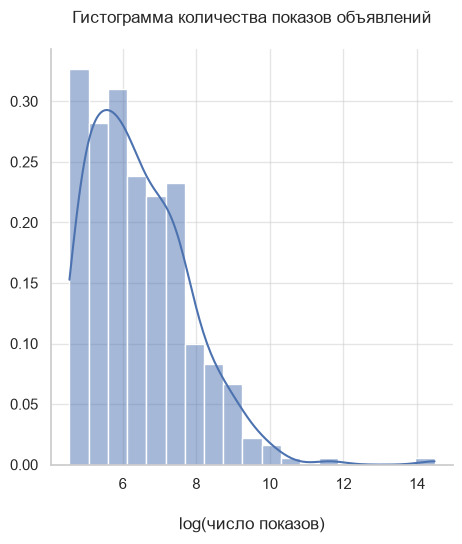

In [11]:
sns.set(
    font_scale=1,
    style="whitegrid",
)

sns.displot(np_view, kde=True, stat='density')
plt.xlabel('\nlog(число показов)')
plt.ylabel(None)
plt.title('Гистограмма количества показов объявлений\n')


In [12]:
# найти среднее количество показов на 1 объявление (ad_id) по дням, не учитывая объявления, у которых не было показов (обычное среднее). После этого посчитайте скользящее среднее по полученному результату с окном в 2 элемента.

ads_data_AvgView = ads_data.query('event == "view"') \
    .groupby(['date', 'ad_id'], as_index=False).size() \
    .pivot_table(index= 'ad_id', columns= 'date', values='size').mean()


ads_data_AvgView

date
2019-04-01      870.800000
2019-04-02     1049.000000
2019-04-03     1200.284916
2019-04-04      841.213333
2019-04-05    13612.885496
2019-04-06     4660.442623
dtype: float64

In [13]:
ads_data_AvgView_rolling = ads_data_AvgView.rolling(2).mean()

round(ads_data_AvgView_rolling, 1)

date
2019-04-01       NaN
2019-04-02     959.9
2019-04-03    1124.6
2019-04-04    1020.7
2019-04-05    7227.0
2019-04-06    9136.7
dtype: float64

In [14]:
#ads_data_AvgView_ewm = ads_data_AvgView.ewm(span=2).mean()

#ads_data_AvgView_ewm

<Axes: xlabel='date'>

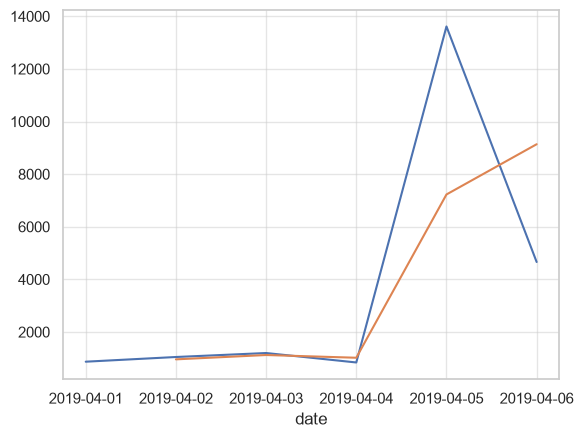

In [66]:
sns.lineplot(ads_data_AvgView)
sns.lineplot(ads_data_AvgView_rolling)

In [16]:
# Найти день с самой большой аномалией

anomaly_date = (ads_data_AvgView.abs() - ads_data_AvgView_rolling.abs()).idxmax()

anomaly_date

Timestamp('2019-04-05 00:00:00')

In [17]:
def max_min_view(x):
    day_view = (ads_data.query('date == @x and event == "view"')
                .groupby('ad_id')
                .size()
                )
    return day_view.idxmax(), day_view.idxmin()

top_view, bottom_view = max_min_view(anomaly_date)

print("Максимум:", top_view)
print("Минимум:", bottom_view)

Максимум: 112583
Минимум: 111067


In [18]:
a = ads_data.query('ad_id == 112583 and date == @anomaly_date and event == "view"')
a

,ad_id,time,event,date,ad_cost_type,has_video,client_union_id,campaign_union_id,platform,ad_cost,target_audience_count,user_id
527124,112583,1554480636,view,2019-04-05,CPM,0,111818,112260,web,199.4,239408,4355
527126,112583,1554480636,view,2019-04-05,CPM,0,111818,112260,android,199.4,239408,2470
527127,112583,1554480636,view,2019-04-05,CPM,0,111818,112260,web,199.4,239408,5435
527128,112583,1554480636,view,2019-04-05,CPM,0,111818,112260,android,199.4,239408,6092
527130,112583,1554480636,view,2019-04-05,CPM,0,111818,112260,android,199.4,239408,4266
...,...,...,...,...,...,...,...,...,...,...,...,...
2811995,112583,1554461715,view,2019-04-05,CPM,0,111818,112260,web,199.4,239408,6250
2812000,112583,1554461742,view,2019-04-05,CPM,0,111818,112260,ios,199.4,239408,5949
2812002,112583,1554461742,view,2019-04-05,CPM,0,111818,112260,android,199.4,239408,6571
2812003,112583,1554461742,view,2019-04-05,CPM,0,111818,112260,ios,199.4,239408,6329


In [19]:
ads_clients_data = pd.read_csv('ads_clients_data.csv', parse_dates = ['create_date', 'date'])

ads_clients_data

,date,client_union_id,community_id,create_date
0,2020-05-07,1,-130371893,2018-12-24
1,2020-05-07,2,-130304626,2019-02-10
2,2020-05-07,3,-130462599,2019-01-25
3,2020-05-07,4,-130574300,2018-12-09
4,2020-05-07,5,-130292358,2019-01-08
...,...,...,...,...
122073,2020-05-07,122074,-130470790,2018-12-21
122074,2020-05-07,122075,-130911261,2018-11-09
122075,2020-05-07,122076,-130494912,2018-10-27
122076,2020-05-07,122077,-130910585,2018-12-05


In [20]:
ads_clients_data.dtypes

date               datetime64[us]
client_union_id             int64
community_id                int64
create_date        datetime64[us]
dtype: object

In [21]:
ads_data.dtypes

ad_id                             int64
time                              int64
event                               str
date                     datetime64[us]
ad_cost_type                        str
has_video                         int64
client_union_id                   int64
campaign_union_id                 int64
platform                            str
ad_cost                         float64
target_audience_count             int64
user_id                           int64
dtype: object

In [36]:
# объединяем только нужные колонки: дату запуска рекламы и дату создания клиента

ads_merged = ads_data[['client_union_id', 'date']].merge(
    ads_clients_data[['client_union_id', 'create_date']],
    on= 'client_union_id', how='left'
)

ads_merged

,client_union_id,date,create_date
0,5681,2019-04-01,2018-10-25
1,111793,2019-04-01,2019-03-06
2,111793,2019-04-01,2019-03-06
3,28541,2019-04-01,2018-11-19
4,5681,2019-04-01,2018-10-25
...,...,...,...
3176709,111818,2019-04-06,2019-01-29
3176710,111818,2019-04-06,2019-01-29
3176711,111818,2019-04-06,2019-01-29
3176712,111818,2019-04-06,2019-01-29


In [37]:
# группируем и делаем чистую таблицу с датой первого запуска рекламы каждого клиента

first_ads = ads_merged.groupby('client_union_id', as_index=False) \
    .agg({'date': 'min',
          'create_date': 'first'})


first_ads

,client_union_id,date,create_date
0,1,2019-04-05,2018-12-24
1,16,2019-04-05,2018-12-19
2,20,2019-04-05,2019-03-01
3,37,2019-04-01,2019-02-22
4,46,2019-04-01,2018-10-01
...,...,...,...
331,121939,2019-04-03,2018-12-23
332,121940,2019-04-02,2019-02-07
333,122042,2019-04-05,2018-12-11
334,122063,2019-04-03,2019-02-23


In [47]:
first_ads['days_to_first_ads'] = first_ads['date'] - first_ads['create_date']

first_ads

,client_union_id,date,create_date,days_to_first_ads
0,1,2019-04-05,2018-12-24,102 days
1,16,2019-04-05,2018-12-19,107 days
2,20,2019-04-05,2019-03-01,35 days
3,37,2019-04-01,2019-02-22,38 days
4,46,2019-04-01,2018-10-01,182 days
...,...,...,...,...
331,121939,2019-04-03,2018-12-23,101 days
332,121940,2019-04-02,2019-02-07,54 days
333,122042,2019-04-05,2018-12-11,115 days
334,122063,2019-04-03,2019-02-23,39 days


In [39]:
# средняя разница в днях между созданием клиента и первым его объявлением
abs(first_ads['date'] - first_ads['create_date']).mean()

Timedelta('123 days 00:55:52.835820')

In [40]:
first_ads.dtypes

client_union_id                int64
date                  datetime64[us]
create_date           datetime64[us]
days_to_first_ads    timedelta64[us]
dtype: object

In [41]:
# вычислим конверсию из создания рекламного кабинета в запуск первой рекламы в течение не более 365 дней НА общее кол-во рекламных клиентов и * 100%

converted = (first_ads['days_to_first_ads'] <= pd.Timedelta(365, unit='day')).sum()

total_clients = ads_clients_data.client_union_id.nunique()

conversion = (converted / total_clients) * 100

print("Конверсия:", round(conversion, 2))

Конверсия: 0.27


In [42]:
# дополнительно найдем клиентов, кто ни разу не запускал рекламу. Для них можем сделать рассылку с предложением, например

ads_merged_2 = ads_clients_data.merge(ads_data, how = 'left', on = 'client_union_id', suffixes= ['_cl_data','_ad_data'])

ads_merged_2

,date_cl_data,client_union_id,community_id,create_date,ad_id,time,event,date_ad_data,ad_cost_type,has_video,campaign_union_id,platform,ad_cost,target_audience_count,user_id
0,2020-05-07,1,-130371893,2018-12-24,3.0,1.554481e+09,view,2019-04-05,CPC,0.0,1.0,android,52.4,52875.0,3181.0
1,2020-05-07,1,-130371893,2018-12-24,3.0,1.554481e+09,view,2019-04-05,CPC,0.0,1.0,android,52.4,52875.0,5349.0
2,2020-05-07,1,-130371893,2018-12-24,3.0,1.554480e+09,view,2019-04-05,CPC,0.0,1.0,android,52.4,52875.0,5521.0
3,2020-05-07,1,-130371893,2018-12-24,3.0,1.554480e+09,view,2019-04-05,CPC,0.0,1.0,web,52.4,52875.0,5219.0
4,2020-05-07,1,-130371893,2018-12-24,3.0,1.554480e+09,view,2019-04-05,CPC,0.0,1.0,web,52.4,52875.0,1341.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3296403,2020-05-07,122074,-130470790,2018-12-21,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3296404,2020-05-07,122075,-130911261,2018-11-09,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3296405,2020-05-07,122076,-130494912,2018-10-27,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3296406,2020-05-07,122077,-130910585,2018-12-05,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
client_ads_count = ads_merged_2.groupby('client_union_id', as_index=False)['ad_id'].nunique().rename(columns = {'ad_id':'ad_count'}).sort_values('ad_count')

client_ads_count

,client_union_id,ad_count
61038,61039,0
81328,81329,0
81327,81328,0
81326,81327,0
81325,81326,0
...,...,...
19,20,2
102534,102535,3
36,37,3
120414,120415,3


In [44]:
clients_without_ads = client_ads_count[client_ads_count['ad_count'] == 0].count()

clients_without_ads

client_union_id    121743
ad_count           121743
dtype: int64

In [57]:
# Разбивка клиентов по времени до первой рекламы от 0 до 365 дней
bins= [pd.Timedelta(days=0),
       pd.Timedelta(days=30),
       pd.Timedelta(days=90),
       pd.Timedelta(days=180),
       pd.Timedelta(days=365)
       ]


first_ads['first_ad_category'] = pd.cut(first_ads['days_to_first_ads'], bins = bins, labels = ['first month', 'first 3 months', 'first halfyear', 'first year'], include_lowest=True)
first_ads

,client_union_id,date,create_date,days_to_first_ads,first_ad_category
0,1,2019-04-05,2018-12-24,102 days,first halfyear
1,16,2019-04-05,2018-12-19,107 days,first halfyear
2,20,2019-04-05,2019-03-01,35 days,first 3 months
3,37,2019-04-01,2019-02-22,38 days,first 3 months
4,46,2019-04-01,2018-10-01,182 days,first year
...,...,...,...,...,...
331,121939,2019-04-03,2018-12-23,101 days,first halfyear
332,121940,2019-04-02,2019-02-07,54 days,first 3 months
333,122042,2019-04-05,2018-12-11,115 days,first halfyear
334,122063,2019-04-03,2019-02-23,39 days,first 3 months


In [59]:
unique_cl_first_ad_30 = first_ads['first_ad_category'].value_counts()
unique_cl_first_ad_30

first_ad_category
first halfyear    165
first 3 months    102
first year         61
first month         7
Name: count, dtype: int64

In [65]:
figg = px.bar( unique_cl_first_ad_30, labels = {'first_ad_category' : 'interval', 'value' : 'clients count'})

figg